# Projet CO2 - Exploration des données

## Contexte

L’objectif de ce projet est d’analyser les émissions de CO2 des véhicules commercialisés en France afin d’identifier les facteurs influençant la pollution.

## Objectif

- Comprendre la structure du jeu de données
- Identifier les variables influençant les émissions de CO2
- Mettre en évidence des tendances à l’aide de visualisations
- Préparer les données pour une future modélisation

In [1]:
print("Projet CO2")

Projet CO2


In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

## Chargement des données 2014

Nous importons le jeu de données contenant les caractéristiques techniques des véhicules commercialisés en France en 2014.

Le fichier est encodé en `latin1` et utilise le séparateur `;`. Ces paramètres doivent être précisés lors de la lecture du fichier avec pandas.

In [3]:
df_2014 = pd.read_csv("../data/co2_2014.csv", encoding="latin1", sep=";")
df_2014.head()

,lib_mrq,lib_mod_doss,lib_mod,dscom,cnit,tvv,cod_cbr,hybride,puiss_admin_98,puiss_max,...,masse_ordma_min,masse_ordma_max,champ_v9,date_maj,Carrosserie,gamme,Unnamed: 26,Unnamed: 27,Unnamed: 28,Unnamed: 29
0,ALFA-ROMEO,159,159,159 1750 Tbi (200ch),M10ALFVP000G340,939AXN1B52C,ES,non,12,147,...,1505,1505,715/2007*692/2008EURO5,mars-14,BERLINE,MOY-SUPER,NaN,NaN,NaN,NaN
1,ALFA-ROMEO,159,159,159 1750 Tbi (200ch),M10ALFVP000H341,939BXN1B53C,ES,non,12,147,...,1555,1555,715/2007*692/2008EURO5,mars-14,BERLINE,MOY-SUPER,NaN,NaN,NaN,NaN
2,ALFA-ROMEO,159,159,159 2.0 JTDm (136ch),M10ALFVP000E302,939AXR1B64,GO,non,7,100,...,1565,1565,715/2007*692/2008EURO5,mars-14,BERLINE,MOY-SUPER,NaN,NaN,NaN,NaN
3,ALFA-ROMEO,159,159,159 2.0 JTDm (136ch),M10ALFVP000F303,939AXR1B64B,GO,non,7,100,...,1565,1565,715/2007*692/2008EURO5,mars-14,BERLINE,MOY-SUPER,NaN,NaN,NaN,NaN
4,ALFA-ROMEO,159,159,159 2.0 JTDm (170ch),M10ALFVP000G304,939AXS1B66,GO,non,9,125,...,1565,1565,715/2007*692/2008EURO5,mars-14,BERLINE,MOY-SUPER,NaN,NaN,NaN,NaN


In [5]:
# Nombre de lignes et colonnes
df_2014.shape

(55044, 30)

Le jeu de données contient 55 044 lignes et 30 colonnes.

In [6]:
# Informations générales
df_2014.info()

<class 'pandas.DataFrame'>
RangeIndex: 55044 entries, 0 to 55043
Data columns (total 30 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   lib_mrq            55044 non-null  str    
 1   lib_mod_doss       55044 non-null  str    
 2   lib_mod            55044 non-null  str    
 3   dscom              55044 non-null  str    
 4   cnit               55044 non-null  str    
 5   tvv                55044 non-null  str    
 6   cod_cbr            55044 non-null  str    
 7   hybride            55044 non-null  str    
 8   puiss_admin_98     55044 non-null  int64  
 9   puiss_max          55044 non-null  str    
 10  typ_boite_nb_rapp  55044 non-null  str    
 11  conso_urb          55001 non-null  str    
 12  conso_exurb        55001 non-null  str    
 13  conso_mixte        55010 non-null  str    
 14  co2                55010 non-null  float64
 15  co_typ_1           54886 non-null  str    
 16  hc                 9773 non-null 

La majorité des variables sont de type object. Certaines variables quantitatives semblent mal typées et devront être converties.

In [7]:
# Statistiques descriptives
df_2014.describe(include='all')

,lib_mrq,lib_mod_doss,lib_mod,dscom,cnit,tvv,cod_cbr,hybride,puiss_admin_98,puiss_max,...,masse_ordma_min,masse_ordma_max,champ_v9,date_maj,Carrosserie,gamme,Unnamed: 26,Unnamed: 27,Unnamed: 28,Unnamed: 29
count,55044,55044,55044,55044,55044,55044,55044,55044,55044.000000,55044,...,55044.000000,55044.000000,54983,3247,55044,55044,0.0,0.0,0.0,0.0
unique,46,483,434,3837,54982,35430,13,2,NaN,232,...,NaN,NaN,35,5,11,7,NaN,NaN,NaN,NaN
top,MERCEDES,VIANO,VIANO,VIANO 2.2 CDI,M10ALFVP000K441,F142ABE,GO,non,NaN,120,...,NaN,NaN,"""715/2007*692/2008EURO5",mars-14,MINIBUS,MOY-INFER,NaN,NaN,NaN,NaN
freq,36220,14031,14031,5874,2,4,49311,54655,NaN,19968,...,NaN,NaN,23979,2810,46107,33438,NaN,NaN,NaN,NaN
mean,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,10.551504,NaN,...,2102.104553,2341.021801,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
std,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,5.126021,NaN,...,294.731715,424.067895,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
min,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.000000,NaN,...,825.000000,825.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
25%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,9.000000,NaN,...,1982.000000,2075.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
50%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,10.000000,NaN,...,2076.000000,2355.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
75%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,10.000000,NaN,...,2246.000000,2709.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


Les statistiques descriptives mettent en évidence une forte diversité des véhicules et certaines colonnes à forte cardinalité.

Certaines variables contiennent un nombre important de valeurs manquantes, notamment hc, hcnox et les colonnes Unnamed.

## Aperçu des données 2014

Les premières lignes du jeu de données permettent d’observer les différentes variables disponibles, comme la marque du véhicule, le type de carburant, la puissance moteur, la masse ou encore les émissions de CO₂.

In [9]:
df_2014.describe()
df_2014.isnull().sum()

lib_mrq                  0
lib_mod_doss             0
lib_mod                  0
dscom                    0
cnit                     0
tvv                      0
cod_cbr                  0
hybride                  0
puiss_admin_98           0
puiss_max                0
typ_boite_nb_rapp        0
conso_urb               43
conso_exurb             43
conso_mixte             34
co2                     34
co_typ_1               158
hc                   45271
nox                    158
hcnox                 9888
ptcl                  2678
masse_ordma_min          0
masse_ordma_max          0
champ_v9                61
date_maj             51797
Carrosserie              0
gamme                    0
Unnamed: 26          55044
Unnamed: 27          55044
Unnamed: 28          55044
Unnamed: 29          55044
dtype: int64

## Structure des données
Le jeu de données 2014 contient 55 044 observations et 30 variables décrivant les caractéristiques techniques et environnementales des véhicules commercialisés en France.

Les variables présentes dans le dataset concernent notamment :

la marque et le modèle des véhicules,
le type de carburant,
la puissance moteur,
la consommation de carburant,
la masse des véhicules,
les émissions polluantes.

On distingue principalement deux types de variables :

des variables catégorielles (object) :
marque,
carburant,
carrosserie,
type de boîte de vitesse,
gamme du véhicule.

des variables numériques (int64 et float64) :
émissions de CO₂,
puissance administrative,
masse du véhicule,
consommation.

L’analyse des types de données met également en évidence plusieurs variables quantitatives stockées au format object. Une conversion sera nécessaire lors des étapes de preprocessing afin de faciliter les analyses statistiques et la modélisation.

Certaines variables présentent des valeurs manquantes, notamment :

hc,
hcnox,
ptcl,
ainsi que les colonnes Unnamed, totalement vides.

Ces colonnes inutiles devront être supprimées afin d’améliorer la qualité du dataset.

Les variables les plus pertinentes pour l’analyse des émissions de CO₂ semblent être :

co2,
conso_mixte,
puiss_max,
masse_ordma_min,
cod_cbr,
hybride.

L’analyse statistique descriptive met en évidence une forte diversité des véhicules présents dans le dataset, avec des écarts importants de puissance, de masse et de consommation.

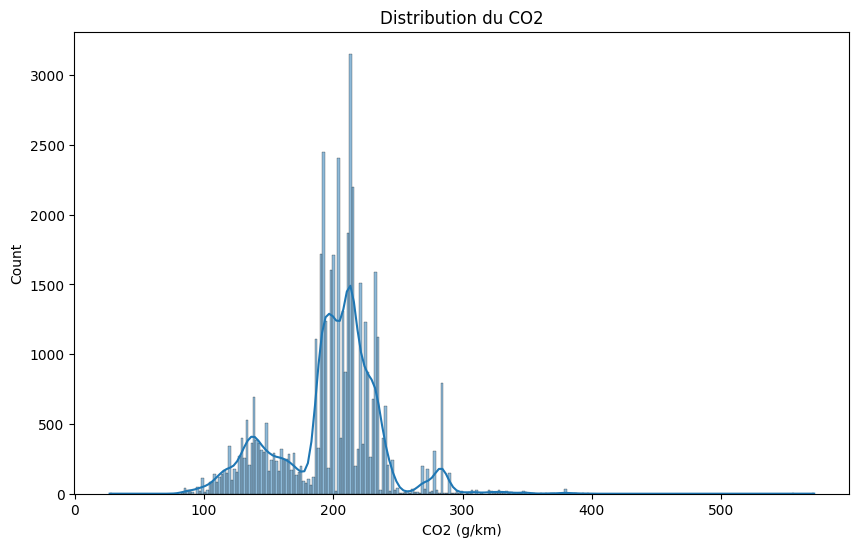

In [9]:
plt.figure(figsize=(10,6))
sns.histplot(df_2013["CO2 (g/km)"], kde=True)
plt.title("Distribution du CO2")
plt.show()

## Distribution des émissions de CO2

La distribution des émissions de CO2 montre une forte concentration des véhicules autour de 150 à 200 g/km.

On observe également une dispersion importante avec quelques valeurs élevées, pouvant dépasser 400 g/km, ce qui correspond à des véhicules plus puissants ou plus énergivores.

La distribution n’est pas parfaitement symétrique et présente une asymétrie vers la droite, indiquant la présence de valeurs extrêmes.

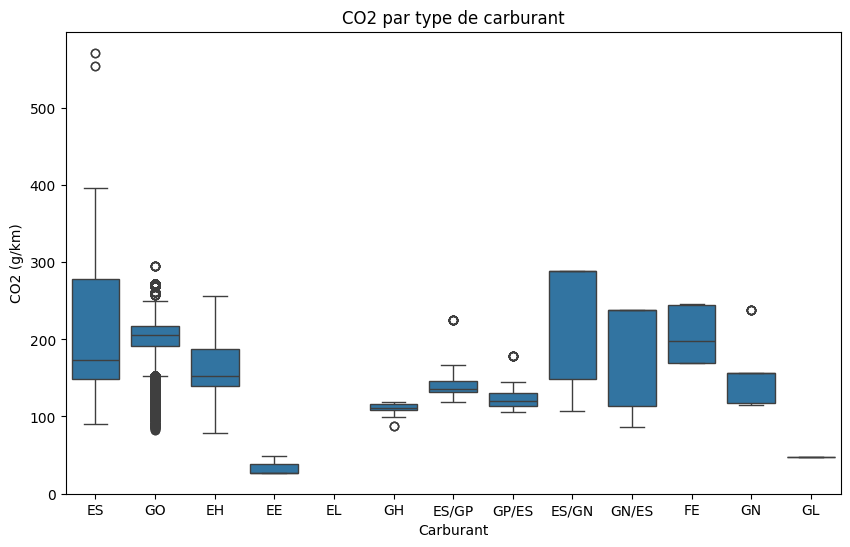

In [11]:
plt.figure(figsize=(10,6))
sns.boxplot(x="Carburant", y="CO2 (g/km)", data=df_2013)
plt.title("CO2 par type de carburant")
plt.show()

## CO2 par type de carburant

L’analyse des émissions de CO2 par type de carburant met en évidence des différences significatives entre les catégories.

Les véhicules essence (ES) présentent une forte dispersion avec des niveaux d’émissions parfois très élevés, notamment en présence de valeurs extrêmes.

Les véhicules diesel (GO) apparaissent plus homogènes, avec une médiane légèrement inférieure.

Les motorisations alternatives (électrique – EE, hybrides – GH, ou GPL/GNV) affichent des niveaux d’émissions globalement plus faibles, bien que certaines catégories présentent une variabilité importante en raison d’un nombre limité d’observations.

Globalement, le type de carburant apparaît comme un facteur déterminant dans le niveau d’émissions de CO2.

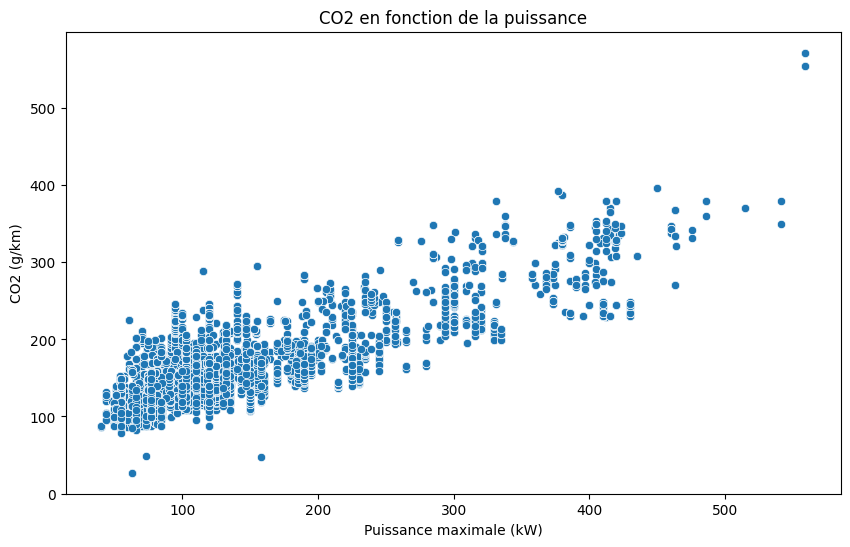

In [17]:
plt.figure(figsize=(10,6))
sns.scatterplot(x="Puissance maximale (kW)", y="CO2 (g/km)", data=df_2013)
plt.title("CO2 en fonction de la puissance")
plt.show()

## Relation entre puissance et émissions de CO2

L’analyse de la relation entre la puissance maximale et les émissions de CO2 met en évidence une corrélation positive.

Plus la puissance du véhicule augmente, plus les émissions de CO2 tendent à être élevées.

Cette tendance est globalement linéaire, bien que l’on observe une dispersion croissante pour les véhicules les plus puissants.

Certains points extrêmes correspondent à des véhicules très puissants, présentant des niveaux d’émissions particulièrement élevés.

La puissance apparaît ainsi comme un facteur déterminant des émissions de CO2.

## Validation statistique

In [21]:
df_2013[["Puissance maximale (kW)", "CO2 (g/km)"]].corr()

,Puissance maximale (kW),CO2 (g/km)
Puissance maximale (kW),1.000000,0.361228
CO2 (g/km),0.361228,1.000000


La relation observée graphiquement entre la puissance et les émissions de CO2 est confirmée par une corrélation positive modérée (0.36) entre ces deux variables.

Cela indique que la puissance influence les émissions de CO2, mais qu’elle n’explique pas à elle seule les variations observées. D’autres facteurs, comme le type de carburant ou la consommation, jouent également un rôle important.

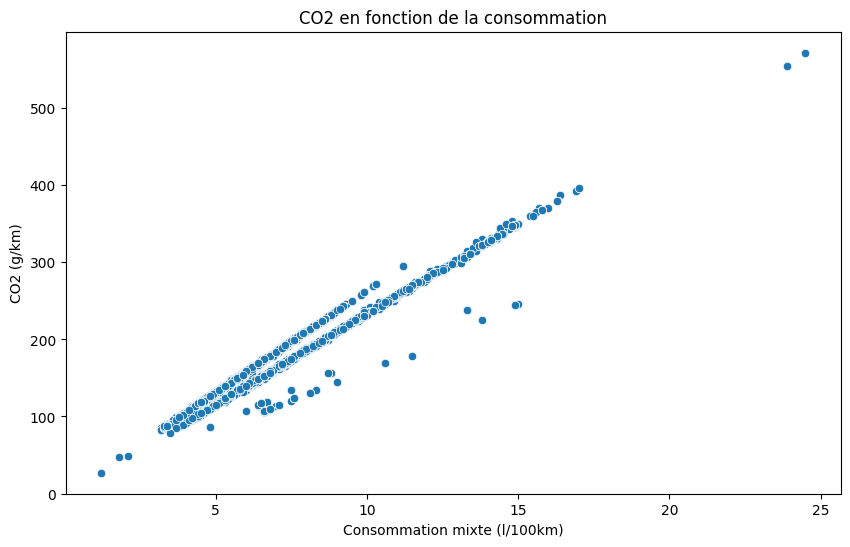

In [23]:
plt.figure(figsize=(10,6))
sns.scatterplot(x="Consommation mixte (l/100km)", y="CO2 (g/km)", data=df_2013)
plt.title("CO2 en fonction de la consommation")
plt.show()

## CO2 en fonction de la consommation

L’analyse de la relation entre la consommation mixte et les émissions de CO2 met en évidence une corrélation très forte et quasi linéaire entre ces deux variables.

Plus un véhicule consomme de carburant, plus il émet de CO2, ce qui est cohérent d’un point de vue physique, puisque la combustion du carburant est directement à l’origine des émissions.

La dispersion des points reste relativement faible autour de la tendance principale, ce qui indique que la consommation est un excellent prédicteur des émissions de CO2.

On observe néanmoins quelques valeurs extrêmes correspondant à des véhicules très énergivores, présentant des niveaux d’émissions particulièrement élevés.

## Validation statistique

In [24]:
df_2013[["Consommation mixte (l/100km)", "CO2 (g/km)"]].corr()

,Consommation mixte (l/100km),CO2 (g/km)
Consommation mixte (l/100km),1.000000,0.959571
CO2 (g/km),0.959571,1.000000


La corrélation calculée entre la consommation et les émissions de CO2 est très élevée (proche de 1), ce qui confirme quantitativement la relation observée graphiquement.

Cela valide que la consommation est le facteur le plus déterminant des émissions de CO2 dans ce jeu de données.

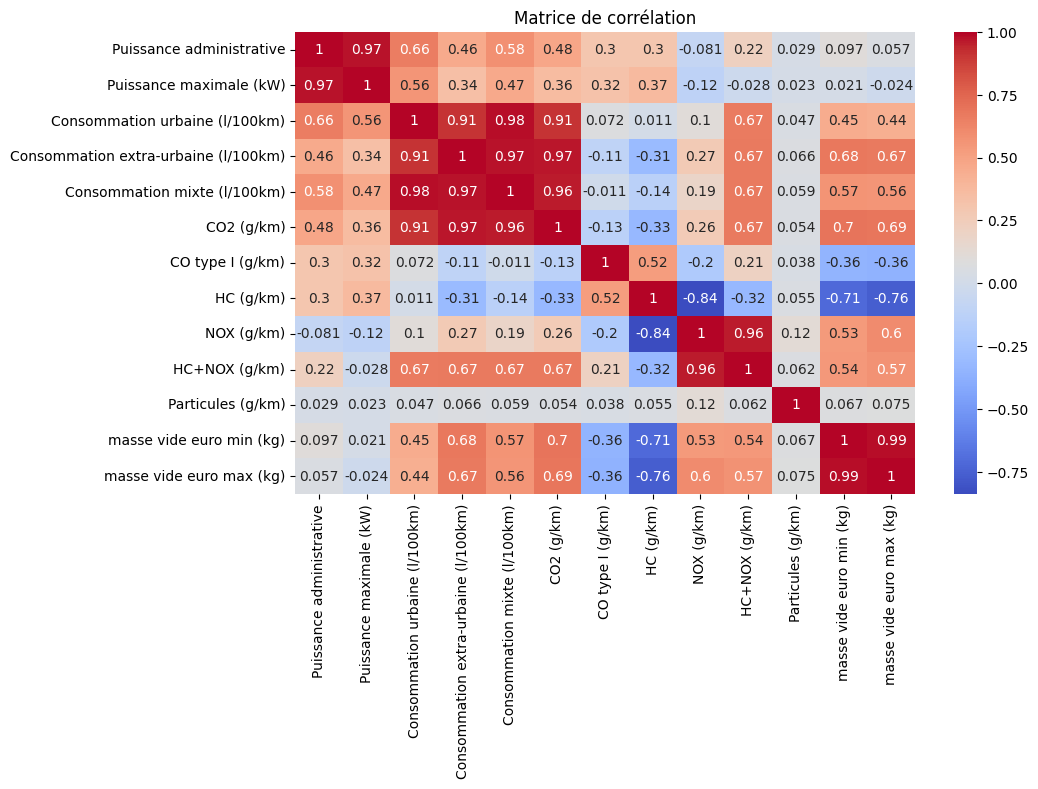

In [25]:
plt.figure(figsize=(10,6))
sns.heatmap(df_2013.corr(numeric_only=True), annot=True, cmap="coolwarm")
plt.title("Matrice de corrélation")
plt.show()

## Analyse des corrélations

La matrice de corrélation permet d’identifier les relations entre les différentes variables numériques du jeu de données.

On observe une très forte corrélation entre les variables de consommation (urbaine, extra-urbaine et mixte) et les émissions de CO2. En particulier, la consommation mixte présente une corrélation très élevée avec le CO2 (proche de 1), ce qui confirme les analyses précédentes.

La puissance maximale est également corrélée positivement avec les émissions de CO2, mais de manière plus modérée.

On remarque aussi des corrélations fortes entre certaines variables techniques, comme les différentes mesures de consommation entre elles, ce qui indique une redondance d’information.

Enfin, certaines variables liées aux polluants (NOX, HC, HC+NOX) présentent des corrélations spécifiques entre elles, traduisant des phénomènes mécaniques propres aux motorisations.

Globalement, la consommation apparaît comme le facteur le plus déterminant des émissions de CO2, devant la puissance ou les autres caractéristiques techniques.

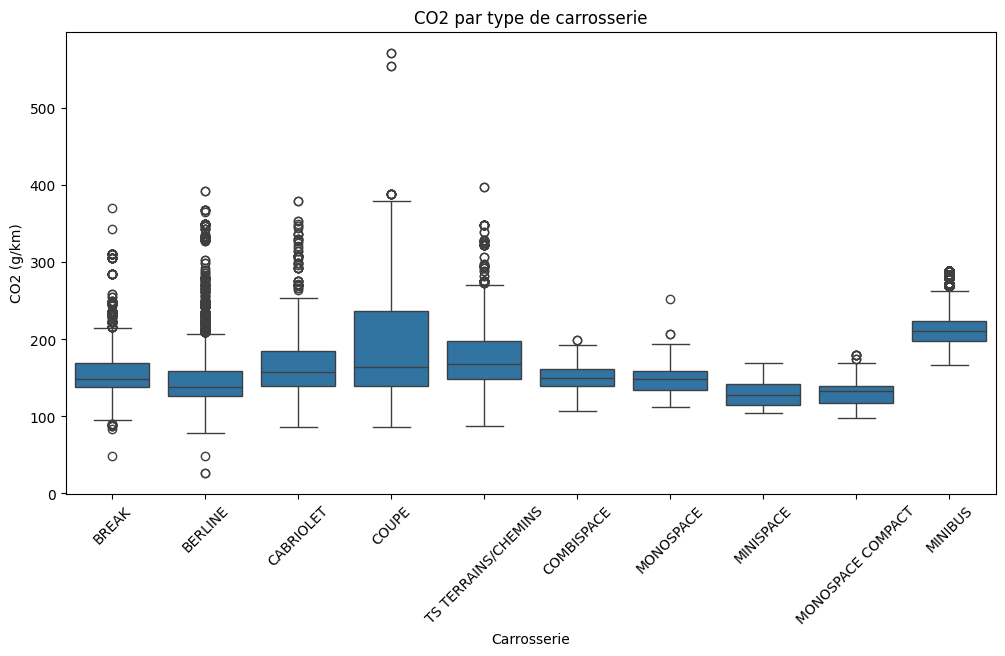

In [26]:
plt.figure(figsize=(12,6))
sns.boxplot(x="Carrosserie", y="CO2 (g/km)", data=df_2013)
plt.xticks(rotation=45)
plt.title("CO2 par type de carrosserie")
plt.show()

## CO2 par type de carrosserie

L’analyse des émissions de CO2 selon le type de carrosserie met en évidence des différences notables entre les catégories de véhicules.

Les véhicules de type coupé ou cabriolet présentent une dispersion importante, avec des niveaux d’émissions parfois élevés, ce qui peut s’expliquer par une orientation plus sportive et des motorisations puissantes.

À l’inverse, les véhicules de type monospace ou minibus affichent des niveaux d’émissions globalement plus élevés en médiane, en raison de leur poids et de leur usage familial nécessitant plus de puissance.

Les citadines et berlines présentent des niveaux d’émissions plus modérés, avec une dispersion moins importante.

Ces observations montrent que la carrosserie, en lien avec le poids et l’usage du véhicule, constitue un facteur influençant les émissions de CO2.

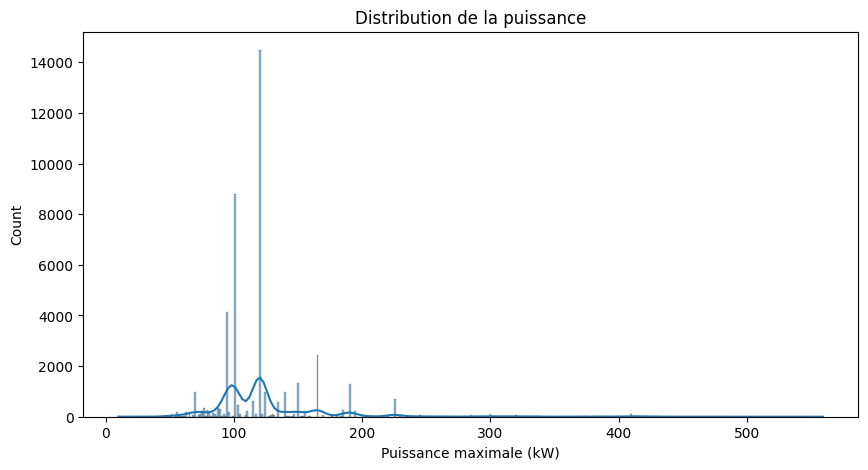

In [28]:
plt.figure(figsize=(10,5))
sns.histplot(df_2013["Puissance maximale (kW)"], kde=True)
plt.title("Distribution de la puissance")
plt.show()

## Distribution de la puissance

La distribution de la puissance maximale des véhicules montre une forte concentration autour de 80 à 150 kW, ce qui correspond à la majorité des véhicules du marché.

On observe une asymétrie vers la droite, avec la présence de véhicules beaucoup plus puissants, pouvant dépasser 300 kW, mais qui restent minoritaires.

Cette distribution confirme que la majorité des véhicules sont de puissance modérée, tandis que les véhicules très puissants constituent des cas particuliers.

Cette répartition permet d’expliquer en partie la dispersion observée dans les émissions de CO2, les véhicules les plus puissants étant généralement plus émetteurs.

## Chargement des données 2014

In [10]:
df_2014 = pd.read_csv("data/mars-2014-complete.csv", encoding="latin1", sep=";")
df_2014.head()

,lib_mrq,lib_mod_doss,lib_mod,dscom,cnit,tvv,cod_cbr,hybride,puiss_admin_98,puiss_max,...,masse_ordma_min,masse_ordma_max,champ_v9,date_maj,Carrosserie,gamme,Unnamed: 26,Unnamed: 27,Unnamed: 28,Unnamed: 29
0,ALFA-ROMEO,159,159,159 1750 Tbi (200ch),M10ALFVP000G340,939AXN1B52C,ES,non,12,147,...,1505,1505,715/2007*692/2008EURO5,mars-14,BERLINE,MOY-SUPER,NaN,NaN,NaN,NaN
1,ALFA-ROMEO,159,159,159 1750 Tbi (200ch),M10ALFVP000H341,939BXN1B53C,ES,non,12,147,...,1555,1555,715/2007*692/2008EURO5,mars-14,BERLINE,MOY-SUPER,NaN,NaN,NaN,NaN
2,ALFA-ROMEO,159,159,159 2.0 JTDm (136ch),M10ALFVP000E302,939AXR1B64,GO,non,7,100,...,1565,1565,715/2007*692/2008EURO5,mars-14,BERLINE,MOY-SUPER,NaN,NaN,NaN,NaN
3,ALFA-ROMEO,159,159,159 2.0 JTDm (136ch),M10ALFVP000F303,939AXR1B64B,GO,non,7,100,...,1565,1565,715/2007*692/2008EURO5,mars-14,BERLINE,MOY-SUPER,NaN,NaN,NaN,NaN
4,ALFA-ROMEO,159,159,159 2.0 JTDm (170ch),M10ALFVP000G304,939AXS1B66,GO,non,9,125,...,1565,1565,715/2007*692/2008EURO5,mars-14,BERLINE,MOY-SUPER,NaN,NaN,NaN,NaN
